In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve
)

In [ ]:
df=pd.read_csv("/content/dataset_07_student_placement_eligibility.csv")
print("Column names:")
print(df.columns.tolist())
print("\nData types:")
display(df.dtypes.to_frame("Data Type"))
print("\nStatistical summary:")
display(df.describe())
print("\nDataset information:")
df.info()

Column names:
['cgpa', 'attendance_pct', 'coding_score', 'projects_completed', 'internship_months', 'backlogs', 'target']

Data types:


,Data Type
cgpa,float64
attendance_pct,float64
coding_score,int64
projects_completed,int64
internship_months,int64
backlogs,int64
target,int64



Statistical summary:


,cgpa,attendance_pct,coding_score,projects_completed,internship_months,backlogs,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,7.262610,50.859510,2.999000,2.976000,30.539000,2.988000,0.50000
std,1.255403,20.161735,1.711119,1.749424,17.195935,1.722447,0.50025
min,4.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.00000
25%,6.470000,37.447500,2.000000,2.000000,16.000000,2.000000,0.00000
50%,7.270000,50.595000,3.000000,3.000000,30.000000,3.000000,0.50000
75%,8.102500,64.027500,4.000000,4.000000,46.000000,4.000000,1.00000
max,10.000000,100.000000,10.000000,9.000000,60.000000,9.000000,1.00000



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cgpa                1000 non-null   float64
 1   attendance_pct      1000 non-null   float64
 2   coding_score        1000 non-null   int64  
 3   projects_completed  1000 non-null   int64  
 4   internship_months   1000 non-null   int64  
 5   backlogs            1000 non-null   int64  
 6   target              1000 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 54.8 KB


In [ ]:
features = [
    'cgpa',
    'attendance_pct',
    'coding_score',
    'projects_completed',
    'internship_months',
    'backlogs'
]
X = df[features].copy()
y = df["target"].copy()
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
display(X.head())

Feature matrix shape: (1000, 6)
Target shape: (1000,)


,cgpa,attendance_pct,coding_score,projects_completed,internship_months,backlogs
0,8.18,76.43,4,3,14,4
1,9.28,46.50,3,3,50,5
2,7.61,30.59,6,2,25,2
3,7.47,50.98,0,4,56,3
4,6.17,25.42,2,2,55,4


In [ ]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])
print(model)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logistic_regression',
                 LogisticRegression(max_iter=1000, random_state=42))])


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
tn, fp, fn, tp = cm.ravel()
print("\nInterpretation:")
print("True Negatives  (TN):", tn)
print("False Positives (FP):", fp)
print("False Negatives (FN):", fn)
print("True Positives  (TP):", tp)

Confusion Matrix:
[[64 27]
 [35 74]]

Interpretation:
True Negatives  (TN): 64
False Positives (FP): 27
False Negatives (FN): 35
True Positives  (TP): 74


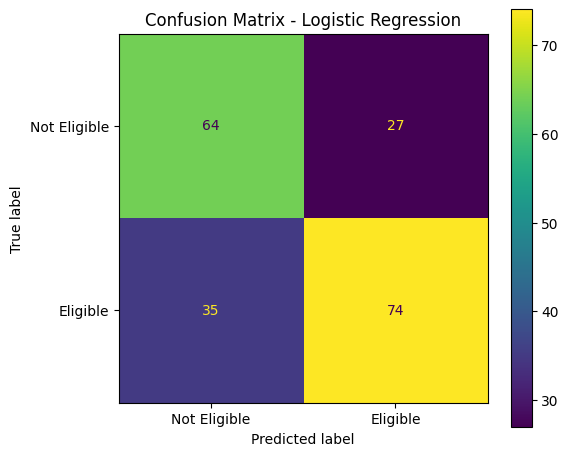

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Eligible", "Eligible"]
)
disp.plot(ax=ax)
ax.set_title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()

In [ ]:
logistic_model = model.named_steps["logistic_regression"]
coefficients = logistic_model.coef_[0]
coefficient_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": coefficients
})
coefficient_df["Absolute_Coefficient"] = (
    coefficient_df["Coefficient"].abs()
)
coefficient_df = coefficient_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
)
display(
    coefficient_df[
        ["Feature", "Coefficient", "Absolute_Coefficient"]
    ].round(4)
)

,Feature,Coefficient,Absolute_Coefficient
5,backlogs,0.6697,0.6697
1,attendance_pct,0.6372,0.6372
3,projects_completed,0.5345,0.5345
2,coding_score,-0.5184,0.5184
0,cgpa,-0.3875,0.3875
4,internship_months,-0.3284,0.3284


In [ ]:
coefficient_df["Odds_Ratio"] = np.exp(
    coefficient_df["Coefficient"]
)
display(
    coefficient_df[
        ["Feature", "Coefficient", "Odds_Ratio"]
    ].round(4)
)

,Feature,Coefficient,Odds_Ratio
5,backlogs,0.6697,1.9536
1,attendance_pct,0.6372,1.8913
3,projects_completed,0.5345,1.7067
2,coding_score,-0.5184,0.5955
0,cgpa,-0.3875,0.6787
4,internship_months,-0.3284,0.7201


In [ ]:
print("=" * 60)
print("FEATURE EFFECT INTERPRETATION")
print("=" * 60)
for _, row in coefficient_df.iterrows():
    feature = row["Feature"]
    coefficient = row["Coefficient"]
    odds_ratio = row["Odds_Ratio"]

    if coefficient > 0:
        direction = "positive"
        effect = "increases"
    elif coefficient < 0:
        direction = "negative"
        effect = "decreases"
    else:
        direction = "neutral"
        effect = "has little/no"
    print(
        f"{feature}: {direction} effect; "
        f"coefficient = {coefficient:.4f}, "
        f"odds ratio = {odds_ratio:.4f}. "
        f"A one-standard-deviation increase {effect} "
        f"the odds of target=1."
    )

FEATURE EFFECT INTERPRETATION
backlogs: positive effect; coefficient = 0.6697, odds ratio = 1.9536. A one-standard-deviation increase increases the odds of target=1.
attendance_pct: positive effect; coefficient = 0.6372, odds ratio = 1.8913. A one-standard-deviation increase increases the odds of target=1.
projects_completed: positive effect; coefficient = 0.5345, odds ratio = 1.7067. A one-standard-deviation increase increases the odds of target=1.
coding_score: negative effect; coefficient = -0.5184, odds ratio = 0.5955. A one-standard-deviation increase decreases the odds of target=1.
cgpa: negative effect; coefficient = -0.3875, odds ratio = 0.6787. A one-standard-deviation increase decreases the odds of target=1.
internship_months: negative effect; coefficient = -0.3284, odds ratio = 0.7201. A one-standard-deviation increase decreases the odds of target=1.


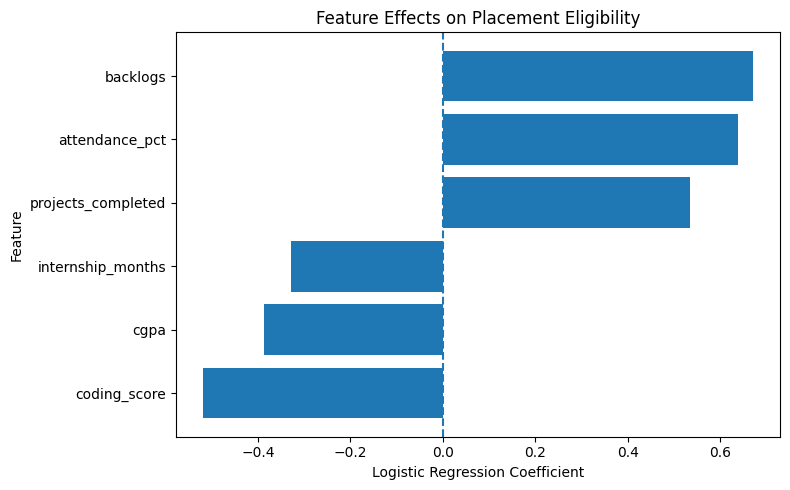

In [ ]:
plot_df = coefficient_df.sort_values("Coefficient")
plt.figure(figsize=(8, 5))
plt.barh(
    plot_df["Feature"],
    plot_df["Coefficient"]
)
plt.axvline(
    x=0,
    linestyle="--"
)
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Feature Effects on Placement Eligibility")
plt.tight_layout()
plt.show()